In [ ]:
California Housing Price Prediction
HW4
Kevin Lopez Sepulveda
CS677

In [19]:
#Begin With Imports
import numpy as np 
import pandas as pd 
import sklearn
import matplotlib.pyplot as plt 
import seaborn as sns


In [ ]:
(a) fetch_california_housing() is a built-in function from Scikit-Learn that lets you directly download 
and load the California Housing Prices dataset into your Python environment. 
(b) as_frame converts the dataset into a pandas dataframe. housing.frame gives you the complete DataFrame
with all features and the target variable included. 
Two other datasets are: load_iris() – The classic Iris dataset used for classification. It includes measurements of 
iris flowers and their species.
load_wine() – A dataset with chemical properties of different wines, used to classify wine types.

SyntaxError: invalid syntax (1567907331.py, line 1)

In [35]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame  

In [29]:
Feature	Description
MedInc	Median income in block group
HouseAge	Median age of houses in the block
AveRooms	Average number of rooms per household
AveBedrms	Average number of bedrooms per household
Population	Population in the block
AveOccup	Average number of household members
Latitude	Latitude of the block
Longitude	Longitude of the block
Regression label: MedHouseVal (median house value)

There are no NULL values

Unique Latitude values: 862
Unique Longitude values: 844

It is axis=1

to convert the strings to numbers qe use map

Based on the graphs, as Ocean proximity goes up, the 
median house value also increases. In  addition, as Median income increases, the median house value also increases.  




SyntaxError: invalid syntax (1006606067.py, line 1)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Unique Latitude values: 862
Unique Longitude values: 844


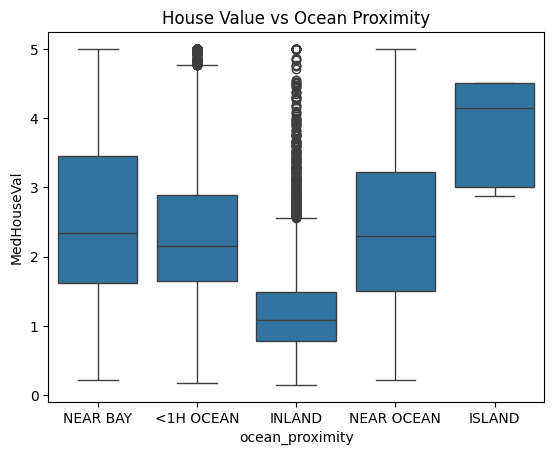

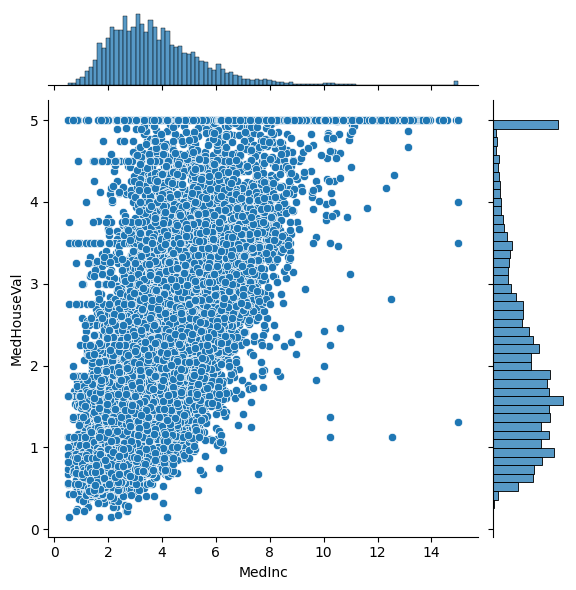

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MedInc           20640 non-null  float64
 1   HouseAge         20640 non-null  float64
 2   AveRooms         20640 non-null  float64
 3   AveBedrms        20640 non-null  float64
 4   Population       20640 non-null  float64
 5   AveOccup         20640 non-null  float64
 6   Latitude         20640 non-null  float64
 7   Longitude        20640 non-null  float64
 8   MedHouseVal      20640 non-null  float64
 9   Unnamed: 0       20640 non-null  int64  
 10  ocean_proximity  20640 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.7 MB
None


In [36]:
# First 3 rows
print(df.head(3))
print(df.columns)
#Null Values
print(df.isnull().sum())
# Unique Lat and Long Values
print("Unique Latitude values:", df['Latitude'].nunique())
print("Unique Longitude values:", df['Longitude'].nunique())
# Read the extra column
ocean_df = pd.read_csv("C:/Users/kevMi/OneDrive/Documents/csFiles-BU/BostonUniversityCS/CS677-BU/64111570(1).csv")
# Combine the two DataFrames
df = pd.concat([df, ocean_df], axis=1)  
# Strip column names of the combined df
df.columns = df.columns.str.strip()
# Create a boxplot of ocean_proximity vs MedHouseVal
sns.boxplot(x='ocean_proximity', y='MedHouseVal', data=df)
plt.title("House Value vs Ocean Proximity")
plt.show()
keys = df['ocean_proximity'].unique()
values = range(len(keys))
proximity_map = {keys[i]: values[i] for i in range(len(keys))}\
# Replace strings with numbers
df['ocean_proximity'] = df['ocean_proximity'].map(proximity_map)
sns.jointplot(x='MedInc', y='MedHouseVal', data=df)
plt.show()
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(numeric_df.info())

Mean Absolute Error (MAE): 9.6492910829971e-14
Root Mean Squared Error (RMSE): 1.4898548665983052e-13


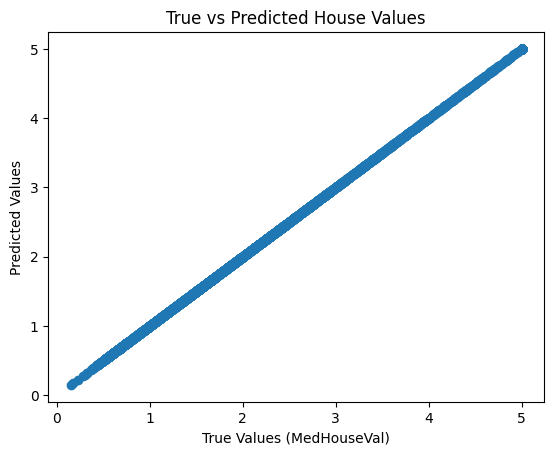

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split into features (X) and labels (y)
X = df.select_dtypes(include=['float64', 'int64'])  # Only numerical columns
y = df['MedHouseVal']  # The label column is MedHouseVal
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression object
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the errors
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

# Scatter plot of test labels vs predicted labels
plt.scatter(y_test, y_pred)
plt.xlabel('True Values (MedHouseVal)')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted House Values')
plt.show()
